# Ficha de Avaliação – UFCD 10810

**Fundamentos do Desenvolvimento de Modelos Analíticos em Python**

**Objetivo**:  Avaliar  a  aplicação  de  conhecimentos  em  modelos  analíticos  supervisionados  e  não  supervisionados, com base em datasets reais e públicos.


Os Exercícios 1 e 2 são totalmente orientados, pelo que bastará reproduzir o código. Se quiseres podes acrescentar melhorias.

No final são apresentados dois exercícios que deverás resolver autonomamente.

**Por fim, anexa todos os ficheiros ou ficheiro obtidos na resolução desta Ficha à secção correspondente no moodle.**

---

# Exercício 1 – Clustering com K-Means (Modelo Não Supervisionado)
(5 valores)

Faz o download do dataset  em https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation 

**Contexto**:
Pretende-se segmentar clientes de um centro comercial com base nas suas características de consumo, para apoiar ações de marketing direcionado. 

**Passos obrigatórios**:
1. Carregar e explorar os dados (verificar colunas e tipos). 
2. Aplicar pré-processamento: 
    a. Tratar valores ausentes, se existirem. 
    b. Normalizar as colunas numéricas. 
    c. Codificar variáveis categóricas com OneHotEncoder, se necessário. 
3. Determinar o número ideal de clusters usando o **Modelo do Cotovelo**. 
4. Aplicar **K-Means** com o número ótimo de clusters. 
5. Avaliar o clustering com o **Coeficiente de Silhueta**. 
6. Visualizar os clusters em 2D com **PCA**.
7. Interpretar os grupos formados (ex: características dos clientes por grupo)

In [100]:
# exercicio1_kmeans_mall.py

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

In [101]:
# 1. Carregar dados 
df = pd.read_csv("data/Mall_Customers.csv")
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [102]:
# 2. Pré-processamento 
# Verificar e remover colunas não numéricas ou pouco informativas 
df = df.drop("CustomerID", axis=1) 

In [103]:
# One-hot encoding da coluna 'Genre' 
df = pd.get_dummies(df, columns=["Genre"], drop_first=True)

In [104]:
# Normalização
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

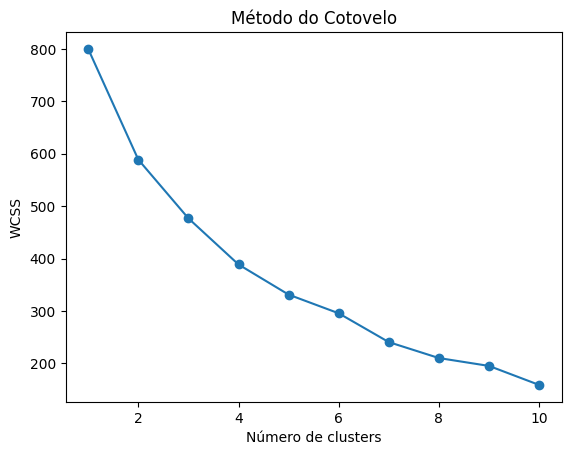

In [105]:
# 3. Modelo do Cotovelo 
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o') 
plt.title("Método do Cotovelo") 
plt.xlabel("Número de clusters") 
plt.ylabel("WCSS") 
plt.show()

In [106]:
# 4. Aplicar KMeans com k=5 (por exemplo)
k = 5 
kmeans = KMeans(n_clusters=k, random_state=0) 
clusters = kmeans.fit_predict(scaled_data)

In [107]:
# 5. Avaliar com coeficiente de silhueta
score = silhouette_score(scaled_data, clusters)
print(f"Coeficiente de Silhueta: {score:.2f}") 

Coeficiente de Silhueta: 0.32


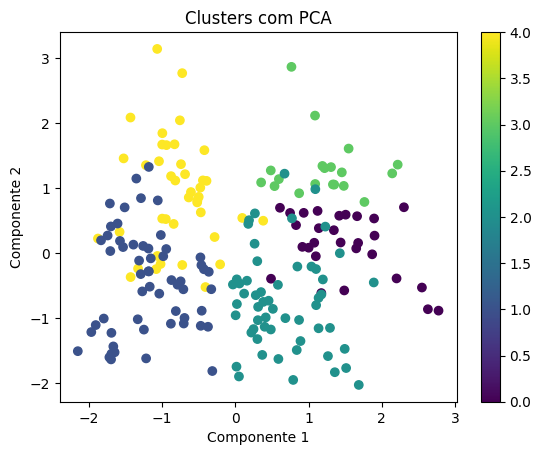

In [108]:
# 6. Visualizar com PCA
pca = PCA(n_components=2) 
pca_data = pca.fit_transform(scaled_data)  

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis') 
plt.title("Clusters com PCA") 
plt.xlabel("Componente 1") 
plt.ylabel("Componente 2") 
plt.colorbar() 
plt.show()

---

# Exercício 2 – Modelo Supervisionado (Classificação com Random Forest) 
(5 valores)

Dataset: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci

**Contexto**: 
Pretende-se prever a presença de doença cardíaca a partir de dados clínicos.

**Passos obrigatórios**:
 1. Carregar e explorar os dados. 
 2. Aplicar pré-processamento: 
    a. Normalizar variáveis numéricas. 
    b. Codificar variáveis categóricas com OneHotEncoder. 
    c. Verificar e remover outliers (usar **IQR** e/ou **Z-score**). 
3. Separar dados em treino/teste com **stratificação**. 
4. Aplicar o modelo **Random Forest** com validação cruzada. 
5. Otimizar hiperparâmetros com **GridSearchCV**. 
6. Avaliar o modelo com: 
    a. **Matriz de confusão** 
    b. **Acurácia, Precisão, Revocação, F1-score** 
7. Comparar desempenho antes e depois da otimização 
8. Prever o risco de doença para um novo paciente (valores fictícios).

In [109]:
# exercicio2_randomforest_heart.py (sem scipy) 
import pandas as pd 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

In [110]:
# 1. Carregar dados 
df = pd.read_csv("data/heart_cleveland_upload.csv") 
print("Colunas disponíveis:", df.columns.tolist()) 
print(df.head())

Colunas disponíveis: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


In [111]:
# 2. Definir variáveis categóricas e numéricas com base na descrição 
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'] 
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

In [112]:
# 3. Remover outliers com base no IQR 
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    filtro = (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)
    df = df[filtro] 

In [113]:
# 4. Separar X e y 
X = df[categorical_cols + numerical_cols] 
y = df["condition"]

In [114]:
# 5. Dividir treino/teste com estratificação 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
) 

In [115]:
# 6. Pipeline com pré-processamento e modelo

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=0))
])


In [116]:
# 7. Validação cruzada 
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(f"Acurácia média (antes da otimização): {cv_scores.mean():.2f}") 

Acurácia média (antes da otimização): 0.81


In [117]:
# 8. Otimização com GridSearchCV 
param_grid = {
    "clf__n_estimators": [50, 100],
    "clf__max_depth": [None, 10, 20]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [None, 10, ...], 'clf__n_estimators': [50, 100]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [118]:
# 9. Avaliação do modelo
y_pred = grid.predict(X_test)
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Matriz de Confusão:
 [[29  2]
 [ 6 16]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88        31
           1       0.89      0.73      0.80        22

    accuracy                           0.85        53
   macro avg       0.86      0.83      0.84        53
weighted avg       0.85      0.85      0.85        53



In [119]:
# 10. Previsão para novo paciente (valores médios fictícios) 
novo_paciente = pd.DataFrame([{
    'age': 55, 'trestbps': 130, 'chol': 245, 'thalach': 150,
    'oldpeak': 1.0, 'ca': 0, 'sex': 1, 'cp': 1, 'fbs': 0,
    'restecg': 1, 'exang': 0, 'slope': 2, 'thal': 2
}])

pred_novo = grid.predict(novo_paciente) 
print(f"\nRisco previsto para novo paciente: {'Doente' if pred_novo[0] == 1 else 'Saudável'}")


Risco previsto para novo paciente: Saudável


In [120]:
# 10. Previsão para novo paciente (valores médios fictícios) 
novo_paciente = pd.DataFrame([{
    'age': 55, 'trestbps': 128, 'chol': 245, 'thalach': 150,
    'oldpeak': 1.0, 'ca': 0, 'sex': 1, 'cp': 1, 'fbs': 0,
    'restecg': 1, 'exang': 0, 'slope': 2, 'thal': 2
}])

pred_novo = grid.predict(novo_paciente) 
print(f"\nRisco previsto para novo paciente: {'Doente' if pred_novo[0] == 1 else 'Saudável'}")


Risco previsto para novo paciente: Doente


---

# Exercício 3 – Modelo Supervisionado (Classificação com K-Nearest Neighbors) 
(5-valores)

Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction


**Contexto**:
Pretende-se prever se um paciente corre risco de falecer devido a insuficiência cardíaca, com base em dados clínicos.
 
**Tarefas**: 

1. Carregar e explorar os dados (verificar colunas e tipos). 
2. Aplicar pré-processamento: 
    * Tratar valores ausentes, se existirem. 
    * Normalizar variáveis numéricas.
    * Codificar variáveis categóricas com OneHotEncoder. 
    * Verificar e remover outliers com **IQR**. 
3. Separar os dados em treino/teste com **stratificação**. 
4. Aplicar um modelo **K-Nearest Neighbors (KNN)**. 
5. Avaliar o modelo com: 
    * **Matriz de confusão**
    * **Acurácia, Precisão, Revocação e F1-score** 
6. Otimizar o número de vizinhos com **GridSearchCV**.
7. Comparar o desempenho antes e depois da otimização. 
8. Prever a condição de um novo paciente (com valores fictícios).

In [121]:
# importanção das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [123]:
# 1. Carregar e explorar dados
df = pd.read_csv("data/heart.csv", sep=',')    # ajuste caminho se necessário
print("Shape:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())

Shape: (918, 12)

Primeiras linhas:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [124]:
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isna().sum())


Tipos de dados:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Valores ausentes por coluna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [125]:
# 2. Pré-processamento

# Categóricas (strings ou flags)
categorical_cols = [
    'Sex',             # M / F
    'ChestPainType',   # ATA / NAP / ASY / TA
    'FastingBS',       # 0 / 1   (pode tratar como categórica porque é flag)
    'RestingECG',      # Normal / LVH / ST
    'ExerciseAngina',  # Y / N
    'ST_Slope'         # Up / Flat / Down
]

# Numéricas contínuas
numerical_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

# Target
target_col = 'HeartDisease'   # 0 = não, 1 = sim

In [126]:
# 2a. Tratar missing (dataset não tem, mas deixamos preparado)
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

In [127]:
# 2b. Remover outliers com IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)
    df = df[mask]

In [128]:
# 3. Separar treino/teste com estratificação
X = df[categorical_cols + numerical_cols]
y = df["HeartDisease"]

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [130]:
# 4. Pipeline com pré-processamento e KNN
preproc = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

pipe = Pipeline([
    ("prep", preproc),
    ("clf", KNeighborsClassifier())
])


Acurácia média inicial: 0.843

Classificação (modelo inicial):
              precision    recall  f1-score   support

           0       0.88      0.78      0.83        76
           1       0.77      0.88      0.82        65

    accuracy                           0.82       141
   macro avg       0.83      0.83      0.82       141
weighted avg       0.83      0.82      0.82       141



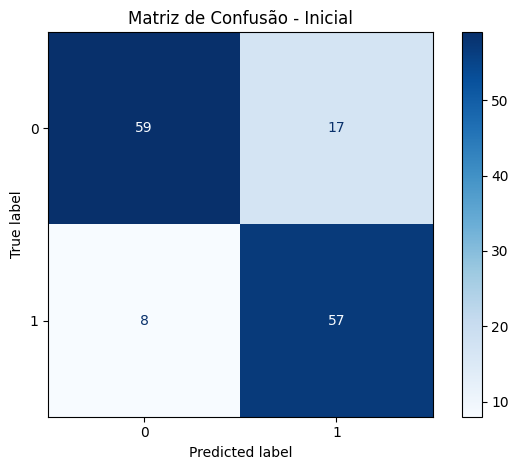

In [131]:
# 5. Avaliação inicial
cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nAcurácia média inicial: {cv_scores.mean():.3f}")

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\nClassificação (modelo inicial):")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Matriz de Confusão - Inicial")
plt.tight_layout()
plt.show()

In [132]:
# 6. Otimização com GridSearchCV
param_grid = {
    "clf__n_neighbors": list(range(3, 21, 2)),
    "clf__weights": ["uniform", "distance"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("\nMelhores parâmetros:", grid.best_params_)
print(f"Acurácia otimizada (CV): {grid.best_score_:.3f}")



Melhores parâmetros: {'clf__n_neighbors': 15, 'clf__weights': 'distance'}
Acurácia otimizada (CV): 0.871



Classificação (modelo otimizado):
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        76
           1       0.77      0.85      0.81        65

    accuracy                           0.82       141
   macro avg       0.82      0.82      0.82       141
weighted avg       0.82      0.82      0.82       141



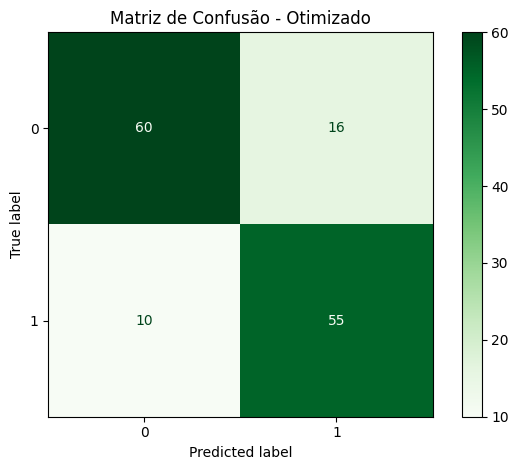

In [133]:
# 7. Avaliação otimizada
best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("\nClassificação (modelo otimizado):")
print(classification_report(y_test, y_pred_opt))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_opt)).plot(cmap="Greens")
plt.title("Matriz de Confusão - Otimizado")
plt.tight_layout()
plt.show()

In [134]:
# 8. Previsão para novo paciente (exemplo)
novo = pd.DataFrame([{
    'Age': 54, 'Sex': 'M', 'ChestPainType': 'ASY',
    'RestingBP': 135, 'Cholesterol': 250, 'FastingBS': 1,
    'RestingECG': 'Normal', 'MaxHR': 140, 'ExerciseAngina': 'Y',
    'Oldpeak': 1.5, 'ST_Slope': 'Flat'
}])

risco = best_model.predict(novo)[0]
prob = best_model.predict_proba(novo)[0][1]

print(f"\nRisco previsto: {'Doente' if risco == 1 else 'Saudável'} (Prob: {prob:.2%})")


Risco previsto: Doente (Prob: 94.20%)


---

# Exercício 4 – Modelo Não Supervisionado (Clustering com DBSCAN) 
(5-valores)

Dataset: https://archive.ics.uci.edu/dataset/292/wholesale+customers 

**Contexto**: 
Pretende-se segmentar clientes de uma empresa grossista com base no tipo de produtos que compram, para identificar padrões de consumo e apoiar decisões de negócio. 

**Tarefas**: 
1. Carregar e explorar os dados (verificar colunas e tipos). 
2. Aplicar pré-processamento: 
    * Tratar valores ausentes, se existirem.
    * Normalizar as variáveis numéricas com StandardScaler.
    * Verificar e remover outliers com **IQR**. 
3. Aplicar o algoritmo **DBSCAN** para clustering. 
4. Avaliar o clustering:
    * Número de clusters e de outliers identificados.
    * **Coeficiente de Silhueta**. 
5. Visualizar os clusters em 2D com **PCA**.
6. Interpretar os grupos encontrados (comportamento de compra típico). 

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [136]:
# 1. Carregar e explorar dados
df = pd.read_csv("data/Wholesale_customers_data.csv")
print("Shape:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())

print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isna().sum())

Shape: (440, 8)

Primeiras linhas:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



Tipos de dados:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Valores ausentes por coluna:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [137]:
# 2.a) Tratar valores ausentes (se existirem no futuro)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Imputar valores numéricos (mediana)
if num_cols:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Imputar valores categóricos (moda)
if cat_cols:
    mode_vals = df[cat_cols].mode()
    if not mode_vals.empty:
        df[cat_cols] = df[cat_cols].fillna(mode_vals.iloc[0])

In [138]:
# 2.b) Normalizar variáveis numéricas

# Remover rótulos que enviesam (se existirem)
for col in ["Channel", "Region"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# >>> Recalcular num_cols agora, para garantir que a lista está actualizada
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Aplicar transformação log(1+x)
df[num_cols] = np.log1p(df[num_cols])

In [139]:
# 2.c) Remover outliers com IQR  (lista num_cols já actualizada)
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)
    df = df[mask]

print("Shape após IQR:", df.shape)   # ex.: (318, 6)

Shape após IQR: (395, 6)


In [140]:
# 2.d) **Agora** escalar os dados filtrados
from sklearn.preprocessing import RobustScaler
X_scaled = RobustScaler().fit_transform(df[num_cols])

In [141]:
# 3. DBSCAN (eps e min_samples podem exigir afinação)
dbscan = DBSCAN(eps=0.9, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df["cluster"] = labels          # ✔ comprimentos iguais

In [142]:
# 4. Avaliação do clustering
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nClusters encontrados      : {n_clusters}")
print(f"Clientes marcados como ruído: {n_noise}")

# Silhouette (excluindo ruído)
mask_core = labels != -1
if n_clusters >= 2 and mask_core.sum() > 0:
    sil = silhouette_score(X_scaled[mask_core], labels[mask_core])
    print(f"Coeficiente de Silhueta*  : {sil:.3f}")
    print("* calculado apenas para amostras atribuídas a clusters")
else:
    print("Silhueta não calculada (requer ≥2 clusters e amostras).")


Clusters encontrados      : 1
Clientes marcados como ruído: 60
Silhueta não calculada (requer ≥2 clusters e amostras).


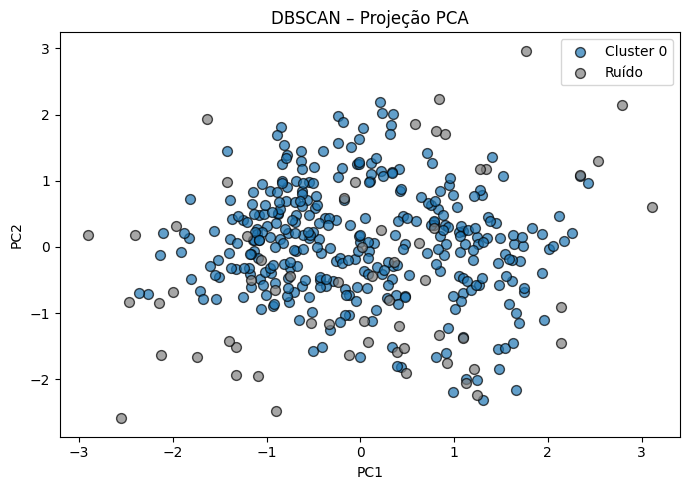

In [143]:
# 5. Visualização 2-D (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
palette = sns.color_palette("tab10", n_clusters)
for lab in set(labels):
    col = 'grey' if lab == -1 else palette[lab % len(palette)]
    plt.scatter(
        X_pca[labels == lab, 0],
        X_pca[labels == lab, 1],
        c=[col],
        label='Ruído' if lab == -1 else f'Cluster {lab}',
        s=50,
        alpha=0.7,
        edgecolor='k'
    )
plt.title("DBSCAN – Projeção PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [144]:
# 6. Interpretação dos clusters (médias de compra)
cluster_profile = (
    df[df["cluster"] != -1]        # ignorar ruído
      .groupby("cluster")[num_cols]
      .mean()
      .round(1)
)

print("\nMédias de cada cluster:")
display(cluster_profile)


Médias de cada cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,9.0,8.1,8.4,7.5,6.9,6.9


In [145]:
# Exemplo de descrição (ajuste após observar resultados):
for cl, row in cluster_profile.iterrows():
    print(f"\n🔹 **Cluster {cl}**")
    top = row.sort_values(ascending=False).head(3)
    print(f"Compradores fortes em: {', '.join(top.index)}")


🔹 **Cluster 0**
Compradores fortes em: Fresh, Grocery, Milk


---
end of file